# CNN-GMM Project — CNN Baseline

**What this notebook does:**
1. Builds a minimal CNN backbone for 20×20×2 input (two conv blocks + FC)
2. Trains it for 50 epochs with class-weighted cross-entropy
3. Evaluates on the held-out test set using the **exact same metric code** as `gp.ipynb`
4. Runs cross-cluster transfer (VCC→FCC and FCC→VCC)
5. Saves all results to `baseline_results.json` for team comparison

**Consistency contract with `gp.ipynb`:**
- Seed: `42` everywhere
- Split: `make_splits(all_frames, seed=42)` → identical rows
- Class weights: `total / (2 * n_class)` formula
- Metrics: `confusion_matrix(...).ravel()` → `tn, fp, fn, tp`
- TPR = `tp / (tp + fn)`, FDR = `fp / (fp + tp)`
- AUC: `roc_auc_score(y_true, y_proba[:, 1])`

---
**Architecture note (from CNN-GMM paper, Alnafea et al. 2024):**  
The original paper uses grouped convolutions with BatchNorm + ReLU after every conv,  
then MaxPool after each block. We follow the same pattern, scaled down for 20×20 input.  
This backbone will later have its FC head replaced by the GMM layers.

## 0 · Seeds — Always First

In [1]:
# Clone
!git clone -b cnn-gmm https://github.com/LuGorr/AII-Assignment.git
!git clone https://github.com/dodo47/GCDetection.git

# Move dataset repo inside assignment repo
!mv GCDetection AII-Assignment/

# Go into assignment
%cd AII-Assignment

# Fix path
import sys, os
sys.path.insert(0, os.getcwd())

# Run
from utils.shared_utils import set_seeds, load_all_frames
set_seeds(42)

Cloning into 'AII-Assignment'...
remote: Enumerating objects: 76, done.
remote: Counting objects: 100% (76/76), done.
remote: Compressing objects: 100% (57/57), done.
remote: Total 76 (delta 6), reused 46 (delta 2), pack-reused 0 (from 0)
Receiving objects: 100% (76/76), 491.64 KiB | 2.00 MiB/s, done.
Resolving deltas: 100% (6/6), done.
Cloning into 'GCDetection'...
remote: Enumerating objects: 263, done.
remote: Counting objects: 100% (49/49), done.
remote: Compressing objects: 100% (26/26), done.
remote: Total 263 (delta 27), reused 42 (delta 23), pack-reused 214 (from 1)
Receiving objects: 100% (263/263), 517.57 MiB | 27.81 MiB/s, done.
Resolving deltas: 100% (52/52), done.
Updating files: 100% (197/197), done.
/content/AII-Assignment
[shared_utils] All seeds set to 42.


## 1 · Imports

In [3]:
import json
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve,
)

from utils.shared_utils import (
    load_all_frames,
    compute_class_weights,
    make_splits,
    make_loader,
    FrameDataset,
)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if device.type == 'cuda':
    print(f'GPU   : {torch.cuda.get_device_name(0)}')
    print(f'VRAM  : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

Device: cuda
GPU   : Tesla T4
VRAM  : 15.6 GB


## 2 · Load Data (identical to gp.ipynb)

In [4]:
all_frames, fcc_df, vcc_df = load_all_frames()
CLASS_WEIGHTS, stats = compute_class_weights(all_frames, device)

train_df, val_df, test_df = make_splits(all_frames, seed=42)

train_dl = make_loader(train_df, batch_size=64, shuffle=True,  num_workers=4)
val_dl   = make_loader(val_df,   batch_size=64, shuffle=False, num_workers=4)
test_dl  = make_loader(test_df,  batch_size=64, shuffle=False, num_workers=4)

print(f"Train: {len(train_df):,}  Val: {len(val_df):,}  Test: {len(test_df):,}")
print(f"GC: {stats['n_pos']:,}  non-GC: {stats['n_neg']:,}")
print(f"CLASS_WEIGHTS → non-GC: {CLASS_WEIGHTS[0]:.4f}  GC: {CLASS_WEIGHTS[1]:.4f}")

Train: 57,418  Val: 8,202  Test: 16,406
GC: 18,151  non-GC: 63,875
CLASS_WEIGHTS → non-GC: 0.6421  GC: 2.2595


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


## 3 · CNN Backbone Architecture

**Design rationale (following CNN-GMM paper structure):**

The CNN-GMM paper (Alnafea et al. 2024) uses:
- Grouped convolutions with `[3×3]` filters
- ReLU + BatchNorm after every convolution
- MaxPool after each block
- A single FC layer before the classification head

We follow the same pattern, scaled for **20×20×2** input:

```
Input:  (B, 2, 20, 20)

Block 1:
  Conv2d(2→16,  3×3, pad=1) → BN → ReLU   → (B, 16, 20, 20)
  Conv2d(16→32, 3×3, pad=1) → BN → ReLU   → (B, 32, 20, 20)
  MaxPool2d(2×2)                            → (B, 32, 10, 10)

Block 2:
  Conv2d(32→64, 3×3, pad=1) → BN → ReLU   → (B, 64, 10, 10)
  Conv2d(64→64, 3×3, pad=1) → BN → ReLU   → (B, 64, 10, 10)
  MaxPool2d(2×2)                            → (B, 64, 5, 5)

Flatten:                                     (B, 1600)

FC head (will be replaced by GMM layers later):
  Linear(1600→256) → BN → ReLU → Dropout(0.4)
  Linear(256→2)                              (B, 2)  ← logits
```

The Dropout(0.4) matches the original paper's value.  
The FC→BN→ReLU→Dropout block is kept as a single `nn.Sequential` so it can be  
**surgically removed** in Week 2 when GMM layers are inserted.

In [5]:
class CNNBackbone(nn.Module):
    """
    Minimal CNN baseline for 20×20×2 GC images.

    Follows the structural pattern of Alnafea et al. (2024):
      - Conv → BN → ReLU (repeated twice per block)
      - MaxPool after each block
      - One FC layer before classification
      - Dropout(0.4) on the FC layer

    The fc_head is kept as a named sub-module so that in the CNN-GMM
    version (Week 2) we can replace it with GMMLayer instances while
    keeping the convolutional feature extractor identical.
    """

    def __init__(self, n_classes: int = 2, dropout: float = 0.4):
        super().__init__()

        # ── Block 1: 2→32 channels, 20×20 → 10×10 ──────────────────────────
        self.block1 = nn.Sequential(
            nn.Conv2d(2, 16, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(16),
            nn.ReLU(inplace=True),
            nn.Conv2d(16, 32, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),   # 20×20 → 10×10
        )

        # ── Block 2: 32→64 channels, 10×10 → 5×5 ───────────────────────────
        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),   # 10×10 → 5×5
        )

        # After block2: 64 × 5 × 5 = 1600 features
        self.flat_dim = 64 * 5 * 5   # = 1600

        # ── FC head (will be replaced by GMM layers in Week 2) ───────────────
        # Kept as a named Sequential for clean surgical removal later.
        # Matches paper: FC → BN → ReLU → Dropout(0.4)
        self.fc_head = nn.Sequential(
            nn.Linear(self.flat_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True),
            nn.Dropout(p=dropout),
        )

        # ── Classifier ───────────────────────────────────────────────────────
        self.classifier = nn.Linear(256, n_classes)

        # ── Weight init (Xavier, matching Glorot init used in GMM paper) ─────
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.xavier_uniform_(m.weight)
            elif isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.BatchNorm2d) or isinstance(m, nn.BatchNorm1d):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        x : (B, 2, 20, 20)
        returns logits : (B, 2)
        """
        x = self.block1(x)           # (B, 32, 10, 10)
        x = self.block2(x)           # (B, 64,  5,  5)
        x = x.flatten(start_dim=1)   # (B, 1600)
        x = self.fc_head(x)          # (B, 256)
        return self.classifier(x)    # (B, 2)

    def feature_map(self, x: torch.Tensor) -> torch.Tensor:
        """Return the 256-d FC representation (useful for GMM replacement later)."""
        x = self.block1(x)
        x = self.block2(x)
        x = x.flatten(start_dim=1)
        return self.fc_head(x)


# ── Sanity check: shapes ────────────────────────────────────────────────────
model = CNNBackbone().to(device)
dummy = torch.zeros(4, 2, 20, 20).to(device)
out   = model(dummy)
feat  = model.feature_map(dummy)

print('Architecture summary')
print(f'  Input shape         : {tuple(dummy.shape)}')
print(f'  Output (logits)     : {tuple(out.shape)}    (expected: (4, 2))')
print(f'  Feature map         : {tuple(feat.shape)}  (expected: (4, 256))')
print()

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'  Trainable params    : {n_params:,}')
print()
print(model)

Architecture summary
  Input shape         : (4, 2, 20, 20)
  Output (logits)     : (4, 2)    (expected: (4, 2))
  Feature map         : (4, 256)  (expected: (4, 256))

  Trainable params    : 471,426

CNNBackbone(
  (block1): Sequential(
    (0): Conv2d(2, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(64, 64, kernel_size=(3

## 4 · Evaluation Functions

These functions are written to be **identical in logic to gp.ipynb**.
The metric computation block is copied verbatim:
```python
tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
tpr = tp / (tp + fn)
fdr = fp / (fp + tp)
auc = roc_auc_score(y_true, y_proba[:, 1])
```

In [6]:
@torch.no_grad()
def predict_dataset(model: nn.Module,
                    loader: DataLoader) -> tuple:
    """
    Run inference over a full DataLoader.

    For the CNN baseline the model is deterministic, so we run one forward
    pass. In the CNN-GMM version (Week 2) this function will be replaced
    with a 200-sample MC version that matches gp.ipynb's predict_dataset.

    Returns
    -------
    y_true  : (N,)   int array
    y_proba : (N, 2) float array  — softmax probabilities
    y_pred  : (N,)   int array    — hard labels at threshold 0.5
    """
    model.eval()
    all_labels, all_probs = [], []

    for x, y in loader:
        x = x.to(device)
        logits = model(x)                            # (B, 2)
        probs  = F.softmax(logits, dim=-1)           # (B, 2)
        all_probs.append(probs.cpu().numpy())
        all_labels.append(y.numpy())

    y_true  = np.concatenate(all_labels)
    y_proba = np.concatenate(all_probs, axis=0)
    y_pred  = (y_proba[:, 1] >= 0.5).astype(int)
    return y_true, y_proba, y_pred


def compute_metrics(y_true: np.ndarray,
                    y_proba: np.ndarray,
                    y_pred: np.ndarray) -> dict:
    """
    Compute TPR, FDR, Accuracy, AUC-ROC.

    Metric definitions — VERBATIM from gp.ipynb §9:
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
        tpr = tp / (tp + fn)
        fdr = fp / (fp + tp)
        auc = roc_auc_score(y_true, y_proba[:, 1])
    """
    cm              = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp  = cm.ravel()
    tpr             = tp / (tp + fn)
    fdr             = fp / (fp + tp) if (fp + tp) > 0 else 0.0
    acc             = (tp + tn) / len(y_true)
    auc             = roc_auc_score(y_true, y_proba[:, 1])
    return dict(TPR=tpr, FDR=fdr, Accuracy=acc, AUC=auc,
                TP=int(tp), FP=int(fp), FN=int(fn), TN=int(tn))


def print_metrics(metrics: dict, tag: str = '') -> None:
    prefix = f'[{tag}] ' if tag else ''
    print(f"{prefix}TPR={metrics['TPR']:.3f}  "
          f"FDR={metrics['FDR']:.3f}  "
          f"Acc={metrics['Accuracy']:.3f}  "
          f"AUC={metrics['AUC']:.3f}")


print('Evaluation functions defined.')

Evaluation functions defined.


## 5 · Training Loop

In [7]:
def train_one_epoch(model: nn.Module,
                    loader: DataLoader,
                    optimizer: torch.optim.Optimizer,
                    criterion: nn.Module) -> dict:
    """
    One training epoch. Returns dict with 'loss' and 'accuracy'.
    Gradient clipping at max_norm=5.0 — matches gp.ipynb.
    """
    model.train()
    total_loss, total_correct, total_samples = 0.0, 0, 0

    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        logits = model(x)
        loss   = criterion(logits, y)
        loss.backward()
        # Gradient clipping — same as gp.ipynb
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimizer.step()

        total_loss    += loss.item() * len(y)
        total_correct += (logits.argmax(1) == y).sum().item()
        total_samples += len(y)

    return dict(
        loss     = total_loss / total_samples,
        accuracy = total_correct / total_samples,
    )


@torch.no_grad()
def validate_epoch(model: nn.Module,
                   loader: DataLoader,
                   criterion: nn.Module) -> dict:
    """
    Validation pass. Also computes TPR and FDR so we can track them per epoch.
    """
    model.eval()
    total_loss, total_correct, total_samples = 0.0, 0, 0
    all_labels, all_probs = [], []

    for x, y in loader:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        loss   = criterion(logits, y)

        total_loss    += loss.item() * len(y)
        total_correct += (logits.argmax(1) == y).sum().item()
        total_samples += len(y)

        probs = F.softmax(logits, dim=-1)
        all_probs.append(probs.cpu().numpy())
        all_labels.append(y.cpu().numpy())

    y_true  = np.concatenate(all_labels)
    y_proba = np.concatenate(all_probs, axis=0)
    y_pred  = (y_proba[:, 1] >= 0.5).astype(int)

    cm             = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    tpr            = tp / (tp + fn)
    fdr            = fp / (fp + tp) if (fp + tp) > 0 else 0.0

    return dict(
        loss     = total_loss / total_samples,
        accuracy = total_correct / total_samples,
        TPR      = tpr,
        FDR      = fdr,
    )


print('Training functions defined.')

Training functions defined.


## 6 · Train the Baseline Model

- **50 epochs**, Adam lr=0.001 — matches gp.ipynb final training
- **CosineAnnealingLR** — matches gp.ipynb scheduler
- **Weighted CrossEntropyLoss** with `CLASS_WEIGHTS` — same formula as gp.ipynb
- Print every 5 epochs: train loss/acc, val loss/acc/TPR/FDR

In [8]:
# ── Hyperparameters ──────────────────────────────────────────────────────────
EPOCHS   = 50
LR       = 1e-3
PRINT_EVERY = 5

# ── Model, loss, optimiser ──────────────────────────────────────────────────
model     = CNNBackbone().to(device)
criterion = nn.CrossEntropyLoss(weight=CLASS_WEIGHTS)   # class-weighted, exact formula
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

# ── History ─────────────────────────────────────────────────────────────────
history = {
    'train_loss': [], 'train_acc': [],
    'val_loss':   [], 'val_acc':   [],
    'val_TPR':    [], 'val_FDR':   [],
}

print(f'Training for {EPOCHS} epochs on {device}')
print(f'Train batches: {len(train_dl)}  Val batches: {len(val_dl)}')
print(f'{"Epoch":>6}  {"Tr loss":>8}  {"Tr acc":>7}  '
      f'{"Val loss":>9}  {"Val acc":>8}  {"Val TPR":>8}  {"Val FDR":>8}')
print('-' * 70)

t0 = time.time()

for epoch in range(EPOCHS):
    tr = train_one_epoch(model, train_dl, optimizer, criterion)
    vl = validate_epoch(model, val_dl, criterion)
    scheduler.step()

    history['train_loss'].append(tr['loss'])
    history['train_acc'].append(tr['accuracy'])
    history['val_loss'].append(vl['loss'])
    history['val_acc'].append(vl['accuracy'])
    history['val_TPR'].append(vl['TPR'])
    history['val_FDR'].append(vl['FDR'])

    if (epoch + 1) % PRINT_EVERY == 0:
        print(f'{epoch+1:6d}  {tr["loss"]:8.4f}  {tr["accuracy"]:7.3f}  '
              f'{vl["loss"]:9.4f}  {vl["accuracy"]:8.3f}  '
              f'{vl["TPR"]:8.3f}  {vl["FDR"]:8.3f}')

elapsed = time.time() - t0
print(f'\nTraining complete in {elapsed/60:.1f} min')

Training for 50 epochs on cuda
Train batches: 898  Val batches: 129
 Epoch   Tr loss   Tr acc   Val loss   Val acc   Val TPR   Val FDR
----------------------------------------------------------------------


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/to

     5    0.1150    0.953     0.7292     0.908     0.608     0.041


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/to

    10    0.0889    0.964     2.1694     0.809     0.144     0.047


...

    40    0.0054    0.998     7.9403     0.803     0.112     0.033


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/to

    45    0.0030    0.999     6.0782     0.823     0.203     0.029


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/to

    50    0.0030    0.999     5.0205     0.835     0.262     0.031

Training complete in 5.6 min


## 7 · Learning Curves

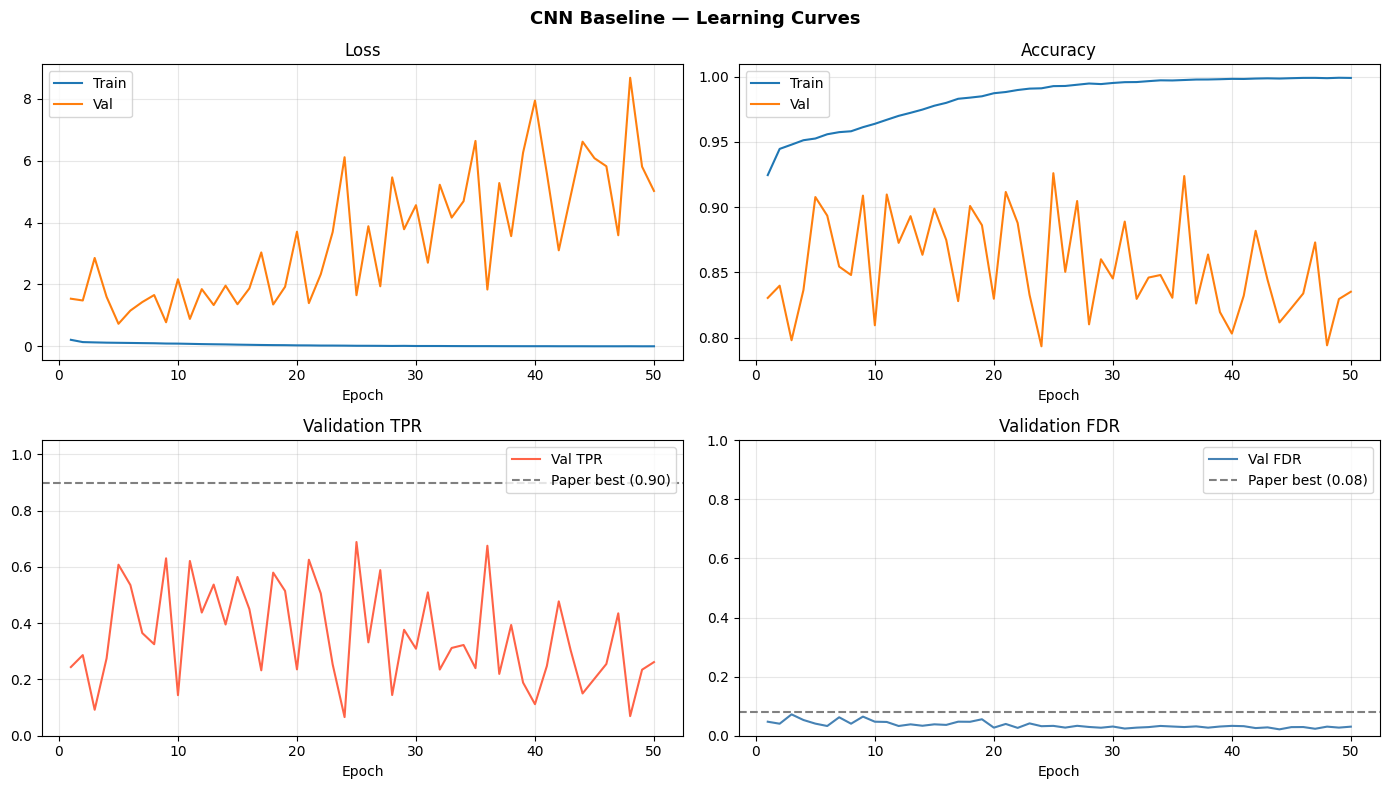

Saved: cnn_baseline_learning_curves.png


In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
epochs_range = range(1, EPOCHS + 1)

axes[0, 0].plot(epochs_range, history['train_loss'], label='Train', lw=1.5)
axes[0, 0].plot(epochs_range, history['val_loss'],   label='Val',   lw=1.5)
axes[0, 0].set_title('Loss');     axes[0, 0].set_xlabel('Epoch'); axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(epochs_range, history['train_acc'], label='Train', lw=1.5)
axes[0, 1].plot(epochs_range, history['val_acc'],   label='Val',   lw=1.5)
axes[0, 1].set_title('Accuracy'); axes[0, 1].set_xlabel('Epoch'); axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].plot(epochs_range, history['val_TPR'], color='tomato',    lw=1.5, label='Val TPR')
axes[1, 0].axhline(0.90, ls='--', color='grey', label='Paper best (0.90)')
axes[1, 0].set_title('Validation TPR'); axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylim(0, 1.05); axes[1, 0].legend(); axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].plot(epochs_range, history['val_FDR'], color='steelblue', lw=1.5, label='Val FDR')
axes[1, 1].axhline(0.08, ls='--', color='grey', label='Paper best (0.08)')
axes[1, 1].set_title('Validation FDR'); axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylim(0, 1.0); axes[1, 1].legend(); axes[1, 1].grid(True, alpha=0.3)

plt.suptitle('CNN Baseline — Learning Curves', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('cnn_baseline_learning_curves.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: cnn_baseline_learning_curves.png')

## 8 · Test-Set Evaluation

Metric code is **verbatim from gp.ipynb §9**.

In [10]:
y_true, y_proba, y_pred = predict_dataset(model, test_dl)

# ── VERBATIM from gp.ipynb §9 ──────────────────────────────────────────────
cm             = confusion_matrix(y_true, y_pred)
tn, fp, fn, tp = cm.ravel()
tpr            = tp / (tp + fn)
fdr            = fp / (fp + tp)
auc            = roc_auc_score(y_true, y_proba[:, 1])
acc            = (tp + tn) / len(y_true)
# ── end verbatim ───────────────────────────────────────────────────────────

print('\n── Test-Set Results (CNN Baseline) ────────────────────────')
print(classification_report(y_true, y_pred, target_names=['non-GC', 'GC']))
print(f'TPR : {tpr:.4f}')
print(f'FDR : {fdr:.4f}')
print(f'Acc : {acc:.4f}')
print(f'AUC : {auc:.4f}')
print()
print(f'TP={tp}  FP={fp}  FN={fn}  TN={tn}')

# Store for final results table
main_results = dict(TPR=tpr, FDR=fdr, Accuracy=acc, AUC=auc,
                    TP=int(tp), FP=int(fp), FN=int(fn), TN=int(tn))

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()



── Test-Set Results (CNN Baseline) ────────────────────────
              precision    recall  f1-score   support

      non-GC       0.83      1.00      0.90     12779
          GC       0.98      0.26      0.41      3627

    accuracy                           0.83     16406
   macro avg       0.90      0.63      0.65     16406
weighted avg       0.86      0.83      0.79     16406

TPR : 0.2553
FDR : 0.0170
Acc : 0.8344
AUC : 0.9682

TP=926  FP=16  FN=2701  TN=12763


## 9 · Test-Set Plots (Confusion Matrix + ROC)

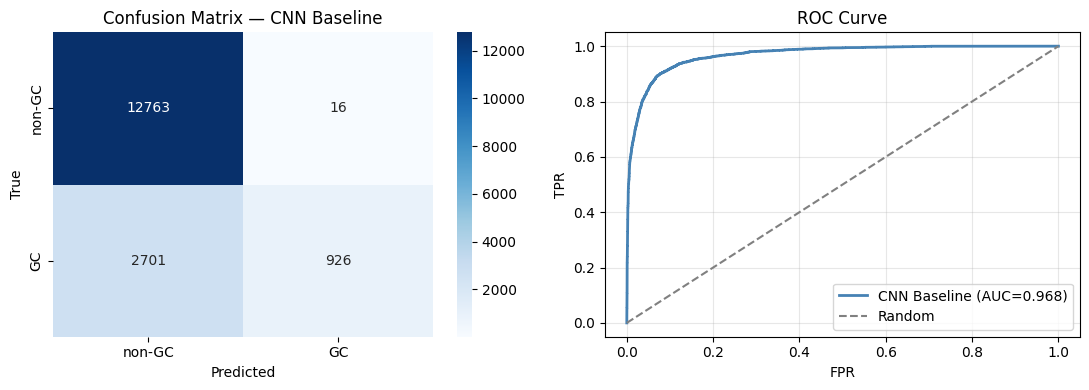

Saved: cnn_baseline_test_results.png


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Confusion matrix — same style as gp.ipynb
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['non-GC', 'GC'],
            yticklabels=['non-GC', 'GC'],
            ax=axes[0])
axes[0].set_ylabel('True'); axes[0].set_xlabel('Predicted')
axes[0].set_title('Confusion Matrix — CNN Baseline')

# ROC curve — same style as gp.ipynb
fpr_arr, tpr_arr, _ = roc_curve(y_true, y_proba[:, 1])
axes[1].plot(fpr_arr, tpr_arr, lw=2, color='steelblue',
             label=f'CNN Baseline (AUC={auc:.3f})')
axes[1].plot([0, 1], [0, 1], '--', color='grey', label='Random')
axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR')
axes[1].set_title('ROC Curve'); axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('cnn_baseline_test_results.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: cnn_baseline_test_results.png')

## 10 · Save Model Checkpoint

In [ ]:
torch.save({
    'model_state_dict' : model.state_dict(),
    'history'          : history,
    'test_metrics'     : main_results,
    'hyperparams'      : {'epochs': EPOCHS, 'lr': LR, 'dropout': 0.4},
    'seed'             : 42,
}, 'cnn_baseline.pth')
print('Checkpoint saved: cnn_baseline.pth')

## 11 · Cross-Cluster Transfer

**Two experiments, matching gp.ipynb §12:**
- Train on **VCC (Virgo)** → test on **FCC (Fornax)**
- Train on **FCC (Fornax)** → test on **VCC (Virgo)**

Class weights recomputed per training set (same formula as above).  
Architecture is identical. Training runs for 30 epochs (matching gp.ipynb's `n_epochs=30`).

In [12]:
def cross_cluster_train_eval(train_df: pd.DataFrame,
                              test_df:  pd.DataFrame,
                              tag:      str,
                              n_epochs: int = 30) -> dict:
    """
    Train a fresh CNNBackbone on `train_df`, evaluate on `test_df`.
    Recomputes class weights from the training set (same formula).
    Mirrors the structure of cross_cluster_eval() in gp.ipynb §12.
    """
    print(f'\n{"="*55}')
    print(f'  {tag}')
    print(f'{"="*55}')
    print(f'  Train: {len(train_df):,}  |  Test: {len(test_df):,}')

    # ── Class weights from the TRAINING set ─────────────────────────────────
    # Same formula as gp.ipynb cross_cluster_eval()
    cnts       = train_df['y'].value_counts()
    n0, n1     = int(cnts.get(False, 1)), int(cnts.get(True, 1))
    tot        = n0 + n1
    cw         = torch.tensor(
        [tot / (2 * n0), tot / (2 * n1)], dtype=torch.float32
    ).to(device)
    print(f'  Class weights → non-GC: {cw[0]:.4f}  GC: {cw[1]:.4f}')

    # ── DataLoaders ──────────────────────────────────────────────────────────
    tr_dl = make_loader(train_df, batch_size=64, shuffle=True,  num_workers=4)
    te_dl = make_loader(test_df,  batch_size=64, shuffle=False, num_workers=4)

    # ── Fresh model ──────────────────────────────────────────────────────────
    cc_model  = CNNBackbone().to(device)
    cc_crit   = nn.CrossEntropyLoss(weight=cw)
    cc_opt    = torch.optim.Adam(cc_model.parameters(), lr=LR)
    cc_sched  = torch.optim.lr_scheduler.CosineAnnealingLR(cc_opt, T_max=n_epochs)

    print(f'  Training for {n_epochs} epochs...')
    for epoch in range(n_epochs):
        train_one_epoch(cc_model, tr_dl, cc_opt, cc_crit)
        cc_sched.step()
        if (epoch + 1) % 10 == 0:
            print(f'    Epoch {epoch+1}/{n_epochs}')

    # ── Evaluate on held-out cluster ─────────────────────────────────────────
    y_t, y_p, y_pred_ = predict_dataset(cc_model, te_dl)

    # VERBATIM from gp.ipynb cross_cluster_eval()
    tn_c, fp_c, fn_c, tp_c = confusion_matrix(y_t, y_pred_).ravel()
    tpr_cc  = tp_c / (tp_c + fn_c)
    fdr_cc  = fp_c / (fp_c + tp_c)
    auc_cc  = roc_auc_score(y_t, y_p[:, 1])
    acc_cc  = (tp_c + tn_c) / len(y_t)

    print(f'  TPR: {tpr_cc:.3f}  FDR: {fdr_cc:.3f}  '
          f'Acc: {acc_cc:.3f}  AUC: {auc_cc:.3f}')

    return dict(tag=tag, TPR=tpr_cc, FDR=fdr_cc,
                Accuracy=acc_cc, AUC=auc_cc,
                TP=int(tp_c), FP=int(fp_c),
                FN=int(fn_c), TN=int(tn_c))


# ── Run both transfer directions ────────────────────────────────────────────
results_vcc_to_fcc = cross_cluster_train_eval(
    vcc_df, fcc_df, 'Train: VCC (Virgo) → Test: FCC (Fornax)', n_epochs=30)

results_fcc_to_vcc = cross_cluster_train_eval(
    fcc_df, vcc_df, 'Train: FCC (Fornax) → Test: VCC (Virgo)', n_epochs=30)


  Train: VCC (Virgo) → Test: FCC (Fornax)
  Train: 61,016  |  Test: 21,010
  Class weights → non-GC: 0.6238  GC: 2.5201
  Training for 30 epochs...


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


    Epoch 10/30
    Epoch 20/30
    Epoch 30/30
  TPR: 0.051  FDR: 0.069  Acc: 0.726  AUC: 0.938

  Train: FCC (Fornax) → Test: VCC (Virgo)
  Train: 21,010  |  Test: 61,016
  Class weights → non-GC: 0.7020  GC: 1.7378


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


  Training for 30 epochs...


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


    Epoch 10/30
    Epoch 20/30
    Epoch 30/30
  TPR: 0.028  FDR: 0.031  Acc: 0.807  AUC: 0.936


## 12 · Cross-Cluster Transfer Plot

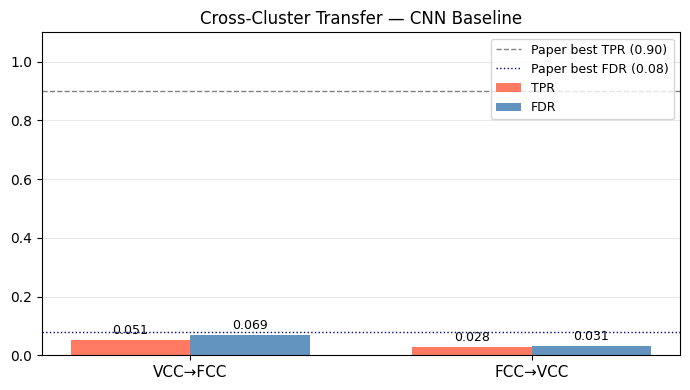

Saved: cnn_baseline_cross_cluster.png


In [13]:
fig, ax = plt.subplots(figsize=(7, 4))

tags = ['VCC→FCC', 'FCC→VCC']
tprs = [results_vcc_to_fcc['TPR'], results_fcc_to_vcc['TPR']]
fdrs = [results_vcc_to_fcc['FDR'], results_fcc_to_vcc['FDR']]
x    = np.arange(len(tags))
w    = 0.35

bars_tpr = ax.bar(x - w/2, tprs, w, label='TPR', color='tomato',    alpha=0.85)
bars_fdr = ax.bar(x + w/2, fdrs, w, label='FDR', color='steelblue', alpha=0.85)

ax.axhline(0.90, color='grey',  ls='--', lw=1, label='Paper best TPR (0.90)')
ax.axhline(0.08, color='navy',  ls=':',  lw=1, label='Paper best FDR (0.08)')

for bar in bars_tpr:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
for bar in bars_fdr:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

ax.set_xticks(x); ax.set_xticklabels(tags, fontsize=11)
ax.set_ylim(0, 1.1)
ax.set_title('Cross-Cluster Transfer — CNN Baseline', fontsize=12)
ax.legend(loc='upper right', fontsize=9)
ax.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('cnn_baseline_cross_cluster.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: cnn_baseline_cross_cluster.png')

## 13 · Final Results Table + Save JSON

In [14]:
all_results = {
    'model'           : 'CNN Baseline',
    'seed'            : 42,
    'epochs'          : EPOCHS,
    'lr'              : LR,
    'mixed_test'      : main_results,
    'vcc_to_fcc'      : results_vcc_to_fcc,
    'fcc_to_vcc'      : results_fcc_to_vcc,
}

with open('baseline_results.json', 'w') as f:
    json.dump(all_results, f, indent=2)
print('Saved: baseline_results.json')

# ── Pretty print the comparison table ───────────────────────────────────────
print()
print('=' * 62)
print(f'{"Experiment":<30} {"TPR":>6} {"FDR":>6} {"Acc":>6} {"AUC":>6}')
print('-' * 62)
for name, res in [
    ('Mixed (VCC+FCC) test',    main_results),
    ('VCC→FCC transfer',        results_vcc_to_fcc),
    ('FCC→VCC transfer',        results_fcc_to_vcc),
]:
    print(f'{name:<30} '
          f'{res["TPR"]:6.3f} '
          f'{res["FDR"]:6.3f} '
          f'{res["Accuracy"]:6.3f} '
          f'{res["AUC"]:6.3f}')
print('=' * 62)
print()
print('Reference (Dold & Fahrion 2022, CNN on mixed test):')
print('  TPR ≈ 0.929   FDR ≈ 0.068   AUC ≈ 0.994')
print()
print('Share baseline_results.json with the team.')
print('This is the anchor for all CNN-GMM comparisons.')

Saved: baseline_results.json

Experiment                        TPR    FDR    Acc    AUC
--------------------------------------------------------------
Mixed (VCC+FCC) test            0.255  0.017  0.834  0.968
VCC→FCC transfer                0.051  0.069  0.726  0.938
FCC→VCC transfer                0.028  0.031  0.807  0.936

Reference (Dold & Fahrion 2022, CNN on mixed test):
  TPR ≈ 0.929   FDR ≈ 0.068   AUC ≈ 0.994

Share baseline_results.json with the team.
This is the anchor for all CNN-GMM comparisons.
